# 05 — Visual Showcase

**FINETUNING_004 · Stain-Robust Pathology Classifier**

Three cells:
1. Load model (ViT-L/16, fine-tuned on AMD MI300X)
2. Classify three H&E patches → Grad-CAM overlay + 9-class probability chart
3. Stain-robustness ablation — the headline result

In [1]:
# ── Bootstrap: load shared library + fine-tuned ViT-L/16 checkpoint ───────────
import json, os
from pathlib import Path
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

_repo   = Path(globals().get('__vsc_ipynb_file__', __file__ if '__file__' in dir() else '.')).parent
_shared = next((p for p in [_repo / 'shared.ipynb',
                              Path('/workspace/finetuning-004-pathology/shared.ipynb')] if p.exists()), None)
assert _shared, 'shared.ipynb not found'
_nb = json.loads(_shared.read_text())
for _cell in _nb['cells']:
    if _cell['cell_type'] == 'code':
        _src = ''.join(_cell['source'])
        _src = '\n'.join(l for l in _src.splitlines()
                         if not l.strip().startswith(('%', 'get_ipython')))
        if _src.strip():
            exec(_src, globals())

PERSIST_DIR = Path(os.environ.get('PERSIST_DIR', '/workspace/shared/ft004'))
RUN_NAME    = 'vit_l_stain'
ck          = load_checkpoint(PERSIST_DIR / 'checkpoints' / RUN_NAME / 'best.pth', map_location='cpu')
cfg, classes = ck['cfg'], ck['classes']
device      = get_device()
model       = build_model(cfg, num_classes=len(classes)).to(device)
raw_module(model).load_state_dict(ck['model'])
model.eval()
cam         = make_gradcam(raw_module(model), cfg['model'])
eval_aug    = build_eval_aug(cfg['img_size'])
print(f'Model ready: {cfg["model"]} on {device}')

def classify(pil_image):
    img = np.array(pil_image.convert('RGB'))
    x   = eval_aug(image=img)['image'].unsqueeze(0).to(device)
    with torch.no_grad():
        probs = model(x).softmax(1)[0]
    top     = int(probs.argmax())
    pred    = classes[top]
    conf    = float(probs[top])
    dist    = {c: float(probs[i]) for i, c in enumerate(classes)}
    raw_arr = np.array(Image.fromarray(img).resize((cfg['img_size'], cfg['img_size'])))
    if cam is not None:
        heat, _ = cam(x, class_idx=top)
        overlay = Image.fromarray(overlay_heatmap(raw_arr, heat))
    else:
        overlay = pil_image
    return pred, conf, dist, overlay

shared.ipynb loaded: Phase A + B + helpers ready.


11:15:30 | INFO | Loading pretrained weights from Hugging Face hub (timm/vit_large_patch16_224.augreg_in21k_ft_in1k)
11:15:30 | INFO | [timm/vit_large_patch16_224.augreg_in21k_ft_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
11:15:30 | INFO | Missing keys (head.weight, head.bias) discovered while loading pretrained weights. This is expected if model is being adapted.


Model ready: vit_l on cuda


TUM → TUM  (90.6%)
STR → STR  (90.9%)
LYM → LYM  (89.0%)


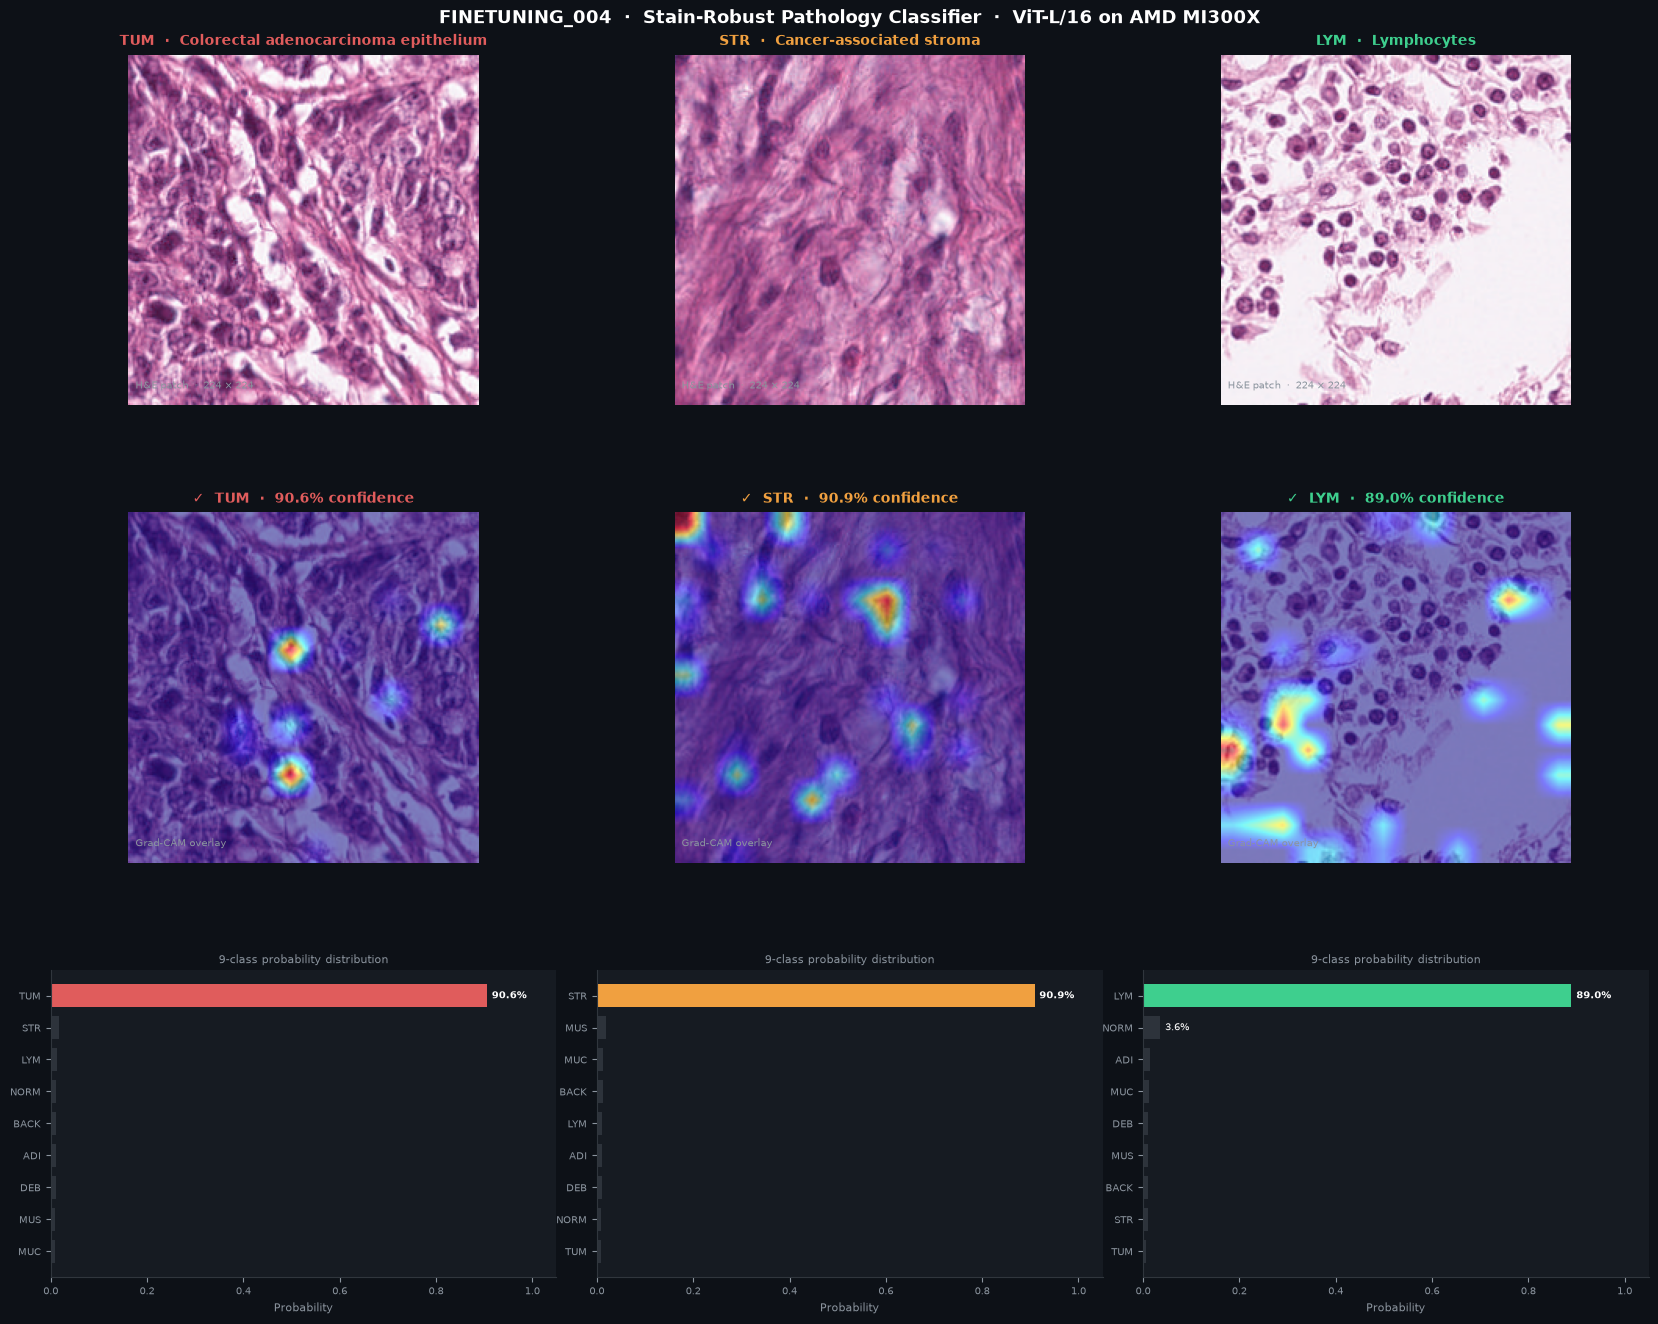

Saved → /workspace/shared/ft004/outputs/showcase.png


In [2]:
# ── Classify three representative patches → full visual breakdown ──────────────
VAL = PERSIST_DIR / 'data' / 'CRC-VAL-HE-7K' / 'CRC-VAL-HE-7K'
DEMO_PATCHES = [
    ('TUM', 'Colorectal adenocarcinoma epithelium', VAL / 'TUM' / 'TUM-TCGA-AAHIDTWA.tif'),
    ('STR', 'Cancer-associated stroma',             VAL / 'STR' / 'STR-TCGA-AAMALCER.tif'),
    ('LYM', 'Lymphocytes',                          VAL / 'LYM' / 'LYM-TCGA-AAWGSCHH.tif'),
]

results = []
for cls, desc, path in DEMO_PATCHES:
    img  = Image.open(path).convert('RGB')
    pred, conf, dist, overlay = classify(img)
    results.append(dict(true=cls, desc=desc, img=img, overlay=overlay,
                        dist=dist, pred=pred, conf=conf))
    print(f'{cls} → {pred}  ({conf*100:.1f}%)')

# ── Figure ─────────────────────────────────────────────────────────────────────
BG   = '#0d1117'
CARD = '#161b22'
COLS = {'TUM': '#e05c5c', 'STR': '#f0a040', 'LYM': '#3ecf8e',
        'ADI': '#60a5fa', 'BACK': '#94a3b8', 'DEB': '#a78bfa',
        'MUC': '#34d399', 'MUS': '#fbbf24', 'NORM': '#4ade80'}

fig = plt.figure(figsize=(17, 13), facecolor=BG)
fig.suptitle(
    'FINETUNING_004  ·  Stain-Robust Pathology Classifier  ·  ViT-L/16 on AMD MI300X',
    color='white', fontsize=13, fontweight='bold', y=0.995
)

outer = gridspec.GridSpec(1, 3, figure=fig, wspace=0.08,
                          left=0.03, right=0.97, top=0.96, bottom=0.02)

for col, r in enumerate(results):
    inner = gridspec.GridSpecFromSubplotSpec(
        3, 1, subplot_spec=outer[col],
        hspace=0.32, height_ratios=[3.2, 3.2, 2.8]
    )
    accent = COLS.get(r['true'], '#ffffff')
    ok     = r['pred'] == r['true']
    tick   = COLS.get(r['pred'], '#00ff88') if ok else '#ff5555'

    # ── row 0: original patch ──────────────────────────────────────────────
    ax0 = fig.add_subplot(inner[0])
    ax0.imshow(r['img'])
    ax0.axis('off')
    ax0.set_facecolor(CARD)
    for sp in ax0.spines.values():
        sp.set_visible(True); sp.set_edgecolor(accent); sp.set_linewidth(2.5)
    ax0.set_title(
        f"{r['true']}  ·  {r['desc']}",
        color=accent, fontsize=10, fontweight='bold', pad=7
    )
    ax0.text(0.02, 0.04, 'H&E patch  ·  224 × 224', transform=ax0.transAxes,
             color='#8b949e', fontsize=7.5, va='bottom')

    # ── row 1: Grad-CAM overlay ────────────────────────────────────────────
    ax1 = fig.add_subplot(inner[1])
    ax1.imshow(r['overlay'])
    ax1.axis('off')
    ax1.set_facecolor(CARD)
    for sp in ax1.spines.values():
        sp.set_visible(True); sp.set_edgecolor(tick); sp.set_linewidth(2.5)
    ax1.set_title(
        f"{'✓' if ok else '✗'}  {r['pred']}  ·  {r['conf']*100:.1f}% confidence",
        color=tick, fontsize=10, fontweight='bold', pad=7
    )
    ax1.text(0.02, 0.04, 'Grad-CAM overlay', transform=ax1.transAxes,
             color='#8b949e', fontsize=7.5, va='bottom')

    # ── row 2: probability bar chart ───────────────────────────────────────
    ax2 = fig.add_subplot(inner[2])
    ax2.set_facecolor(CARD)
    labels = list(r['dist'].keys())
    probs  = list(r['dist'].values())
    order  = sorted(range(len(probs)), key=lambda i: probs[i])
    s_labels = [labels[i] for i in order]
    s_probs  = [probs[i]  for i in order]
    bar_cols = [COLS.get(labels[i], '#60a5fa') if labels[i] == r['pred']
                else '#2d333b' for i in order]
    bars = ax2.barh(s_labels, s_probs, color=bar_cols, edgecolor='none', height=0.72)
    for bar, prob, lbl in zip(bars, s_probs, s_labels):
        if prob > 0.02:
            ax2.text(min(prob + 0.01, 0.97), bar.get_y() + bar.get_height() / 2,
                     f'{prob*100:.1f}%', va='center', color='white', fontsize=7.5,
                     fontweight='bold' if lbl == r['pred'] else 'normal')
    ax2.set_xlim(0, 1.05)
    ax2.set_xlabel('Probability', color='#8b949e', fontsize=8)
    ax2.tick_params(colors='#8b949e', labelsize=7.5)
    for sp in ['top', 'right']:
        ax2.spines[sp].set_visible(False)
    for sp in ['bottom', 'left']:
        ax2.spines[sp].set_color('#30363d')
    ax2.set_title('9-class probability distribution', color='#8b949e', fontsize=8, pad=5)

out_path = PERSIST_DIR / 'outputs' / 'showcase.png'
plt.savefig(out_path, dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'Saved → {out_path}')

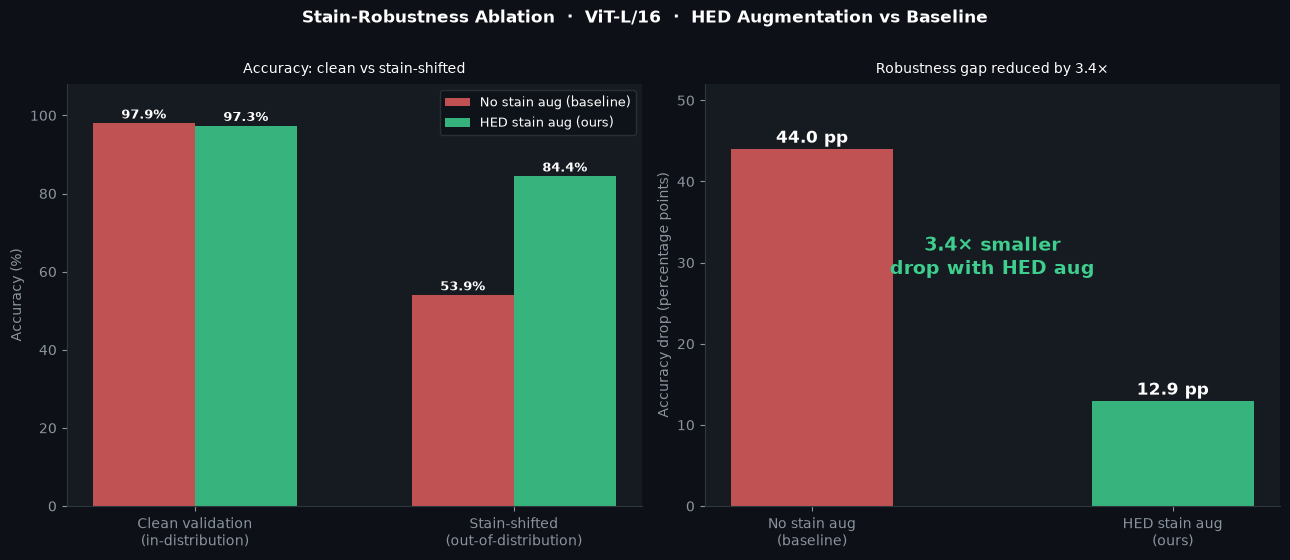

Stain drop:  baseline 44.0 pp  →  ours 12.9 pp  (3.4× reduction)
Saved → /workspace/shared/ft004/outputs/showcase_robustness.png


In [3]:
# ── Headline result: stain-robustness ablation ─────────────────────────────────
import json as _json

stain   = _json.loads((PERSIST_DIR / 'outputs' / 'vit_l_stain_metrics.json').read_text())
nostain = _json.loads((PERSIST_DIR / 'outputs' / 'vit_l_nostain_metrics.json').read_text())

s_clean, s_ood = stain['in_dist']['accuracy'],   stain['ood']['accuracy']
n_clean, n_ood = nostain['in_dist']['accuracy'], nostain['ood']['accuracy']
s_drop, n_drop = stain['ood_drop'], nostain['ood_drop']

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor=BG)
fig.suptitle(
    'Stain-Robustness Ablation  ·  ViT-L/16  ·  HED Augmentation vs Baseline',
    color='white', fontsize=12, fontweight='bold', y=1.01
)

# Left: grouped bar — clean vs OOD accuracy
ax = axes[0]
ax.set_facecolor(CARD)
x      = [0, 1]
width  = 0.32
b1 = ax.bar([v - width/2 for v in x], [n_clean, n_ood], width,
            label='No stain aug (baseline)', color='#e05c5c', alpha=0.85, edgecolor='none')
b2 = ax.bar([v + width/2 for v in x], [s_clean, s_ood],  width,
            label='HED stain aug (ours)',    color='#3ecf8e', alpha=0.85, edgecolor='none')
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h:.1f}%',
            ha='center', va='bottom', color='white', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Clean validation\n(in-distribution)', 'Stain-shifted\n(out-of-distribution)'],
                    color='#8b949e', fontsize=10)
ax.set_ylabel('Accuracy (%)', color='#8b949e', fontsize=10)
ax.set_ylim(0, 108)
ax.tick_params(colors='#8b949e')
ax.legend(facecolor='#0d1117', edgecolor='#30363d', labelcolor='white', fontsize=9)
ax.set_title('Accuracy: clean vs stain-shifted', color='white', fontsize=10, pad=8)
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)
for sp in ['bottom', 'left']:
    ax.spines[sp].set_color('#30363d')

# Right: accuracy drop comparison
ax2 = axes[1]
ax2.set_facecolor(CARD)
bars2 = ax2.bar(['No stain aug\n(baseline)', 'HED stain aug\n(ours)'],
                [n_drop, s_drop],
                color=['#e05c5c', '#3ecf8e'], alpha=0.85, edgecolor='none', width=0.45)
for bar, val in zip(bars2, [n_drop, s_drop]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f} pp', ha='center', va='bottom',
             color='white', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy drop (percentage points)', color='#8b949e', fontsize=10)
ax2.set_ylim(0, 52)
ax2.tick_params(colors='#8b949e')
ax2.set_title(f'Robustness gap reduced by {n_drop/s_drop:.1f}×', color='white', fontsize=10, pad=8)
ax2.text(0.5, 0.55,
         f'{n_drop/s_drop:.1f}× smaller\ndrop with HED aug',
         transform=ax2.transAxes, ha='center', color='#3ecf8e',
         fontsize=14, fontweight='bold')
for sp in ['top', 'right']:
    ax2.spines[sp].set_visible(False)
for sp in ['bottom', 'left']:
    ax2.spines[sp].set_color('#30363d')

plt.tight_layout()
out_path2 = PERSIST_DIR / 'outputs' / 'showcase_robustness.png'
plt.savefig(out_path2, dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'Stain drop:  baseline {n_drop:.1f} pp  →  ours {s_drop:.1f} pp  ({n_drop/s_drop:.1f}× reduction)')
print(f'Saved → {out_path2}')